<a href="https://colab.research.google.com/github/linndemberg1/MachineLearning/blob/main/Aula08_Casa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo de Árvore de Decisão Regressora que aprenda a prever o preço de uma casa com base em:



## *  Tamanho (m²)
## *  Número de quartos





Conjunto de dados:
   Tamanho_m2  Quartos  Preco
0          50        1    150
1          60        2    180
2         100        3    300
3         120        3    340
4         150        4    400
5         180        4    450
6         200        5    480
7         250        5    550
8         300        6    600
9         350        6    680


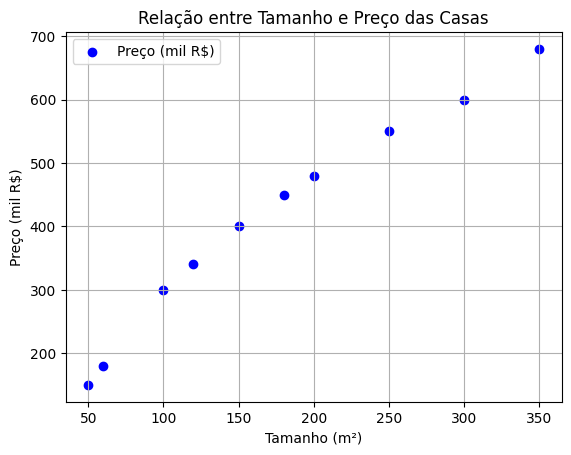

Erro absoluto médio (MAE): 36.67 mil R$
Coeficiente de determinação (R²): 0.95


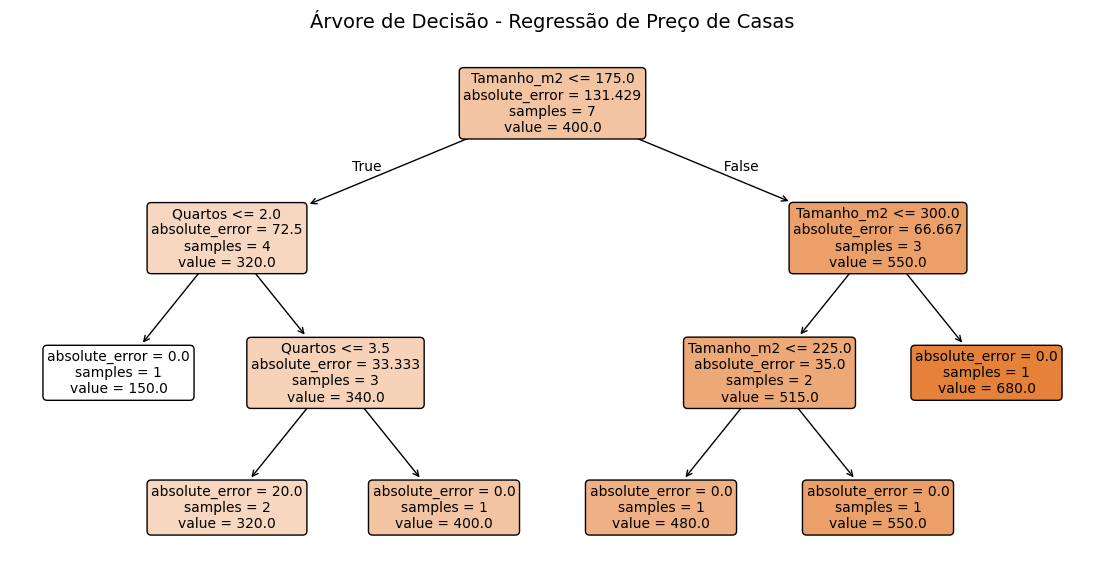

Preço previsto para casa de 180m² e 4 quartos: R$ 480.00 mil


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# -------------------------------------------------------------
# Exemplo 2: Regressão - Preço de Casas
# Autor: Prof. Lindenberg Andrade
# -------------------------------------------------------------

# 1️⃣ Importação das bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# -------------------------------------------------------------
# 2️⃣ Criando um pequeno conjunto de dados (exemplo didático)
# -------------------------------------------------------------
# Cada linha representa uma casa com suas características e preço
dados = pd.DataFrame({
    'Tamanho_m2': [50, 60, 100, 120, 150, 180, 200, 250, 300, 350],
    'Quartos':    [1,   2,   3,   3,   4,   4,   5,   5,   6,   6],
    'Preco':      [150, 180, 300, 340, 400, 450, 480, 550, 600, 680]  # em mil reais
})

print("Conjunto de dados:")
print(dados)

# -------------------------------------------------------------
# 3️⃣ Visualizando os dados (gráfico de dispersão)
# -------------------------------------------------------------
plt.scatter(dados['Tamanho_m2'], dados['Preco'], color='blue', label='Preço (mil R$)')
plt.title("Relação entre Tamanho e Preço das Casas")
plt.xlabel("Tamanho (m²)")
plt.ylabel("Preço (mil R$)")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------------------------------------
# 4️⃣ Separando variáveis de entrada (X) e saída (y)
# -------------------------------------------------------------
X = dados[['Tamanho_m2', 'Quartos']]
y = dados['Preco']

# -------------------------------------------------------------
# 5️⃣ Dividindo em treino e teste
# -------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# -------------------------------------------------------------
# 6️⃣ Criando e treinando o modelo de regressão
# -------------------------------------------------------------
# criterion='absolute_error' → usa erro absoluto como medida de qualidade
# max_depth=3 → limita profundidade da árvore
modelo = DecisionTreeRegressor(criterion='absolute_error', max_depth=3, random_state=42)
modelo.fit(X_train, y_train)

# -------------------------------------------------------------
# 7️⃣ Fazendo previsões
# -------------------------------------------------------------
y_pred = modelo.predict(X_test)

# -------------------------------------------------------------
# 8️⃣ Avaliando o modelo
# -------------------------------------------------------------
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro absoluto médio (MAE): {mae:.2f} mil R$")
print(f"Coeficiente de determinação (R²): {r2:.2f}")

# -------------------------------------------------------------
# 9️⃣ Visualizando a árvore de decisão
# -------------------------------------------------------------
plt.figure(figsize=(14,7))
plot_tree(
    modelo,
    feature_names=['Tamanho_m2', 'Quartos'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árvore de Decisão - Regressão de Preço de Casas", fontsize=14)
plt.show()

# -------------------------------------------------------------
# 🔟 Fazendo uma previsão manual
# -------------------------------------------------------------
# Exemplo: Casa com 180m² e 4 quartos
nova_casa = [[180, 4]]
preco_previsto = modelo.predict(nova_casa)
print(f"Preço previsto para casa de 180m² e 4 quartos: R$ {preco_previsto[0]:.2f} mil")
